In [1]:
import math
import torch
import torch.nn as nn
from torchvision.transforms import v2
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageShow 

In [2]:
mean=0.1307
std=0.3081
batch_size=64
latent_dims=10

In [3]:
transform=v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[mean], std=[std])
])

In [4]:
# Download latest version
train_data = torchvision.datasets.MNIST('data', download=True, transform=transform)
test_data = torchvision.datasets.MNIST('data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=4)
test_loader = torch.utils.data.DataLoader(test_data,
                                           batch_size=batch_size,
                                           shuffle=False,
                                           num_workers=4)

In [23]:
class Encoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, stride=2), # 28->14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1, stride=2), # 14->7
        )

    def forward(self, x):
        return self.net(x)

In [29]:
class Decoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        return self.net(x)

In [30]:
class AutoEncoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [31]:
# Now i need to define the model and an optimiser
autoencoder = AutoEncoder()
optimiser = torch.optim.SGD(autoencoder.parameters(), lr=0.001, momentum=0.9)

In [32]:
# Now i need to define the training loop and, inside, the loss function
n_epochs = 20 

train_batches = len(train_loader)
test_batches = len(test_loader)

train_means = np.empty((n_epochs))
test_means = np.empty((n_epochs))

criterion = nn.MSELoss()
for epoch in range(n_epochs):
    train_loss = 0
    test_loss = 0
    for i, (x_train, _) in enumerate(train_loader):
        optimiser.zero_grad()
        x_hat = autoencoder(x_train)
        loss = criterion(x_hat, x_train)
        train_loss += loss.item()
        loss.backward()
        optimiser.step()
    train_means[epoch] = train_loss / train_batches
    with torch.inference_mode():
        for j, (x_test, _) in enumerate(test_loader):
            x_hat = autoencoder(x_test)
            loss = criterion(x_hat, x_test)
            test_loss += loss.item()
        test_means[epoch] = test_loss / test_batches
    print(f"\r{f'{epoch+1}/{n_epochs}: {i+1}/{train_batches}':<20}", end='', flush=True)

20/20: 938/938      

In [33]:
# Here I shall test the model visually, passing an image through,
# denormalising the result and rendering it with pillow
def denormalise(x):
    return std * x + mean
    
data = test_data[7][0]

output = autoencoder(torch.reshape(data, (1,1,28,28)))[0][0]
restored_output = (255 * torch.clamp(denormalise(output), 0, 1)).to(torch.uint8)
img_hat = Image.fromarray(restored_output.detach().numpy())

restored_data = (255 * denormalise(data)).to(torch.uint8)[0]
img = Image.fromarray(restored_data.numpy())
ImageShow.show(img_hat)
ImageShow.show(img)

True

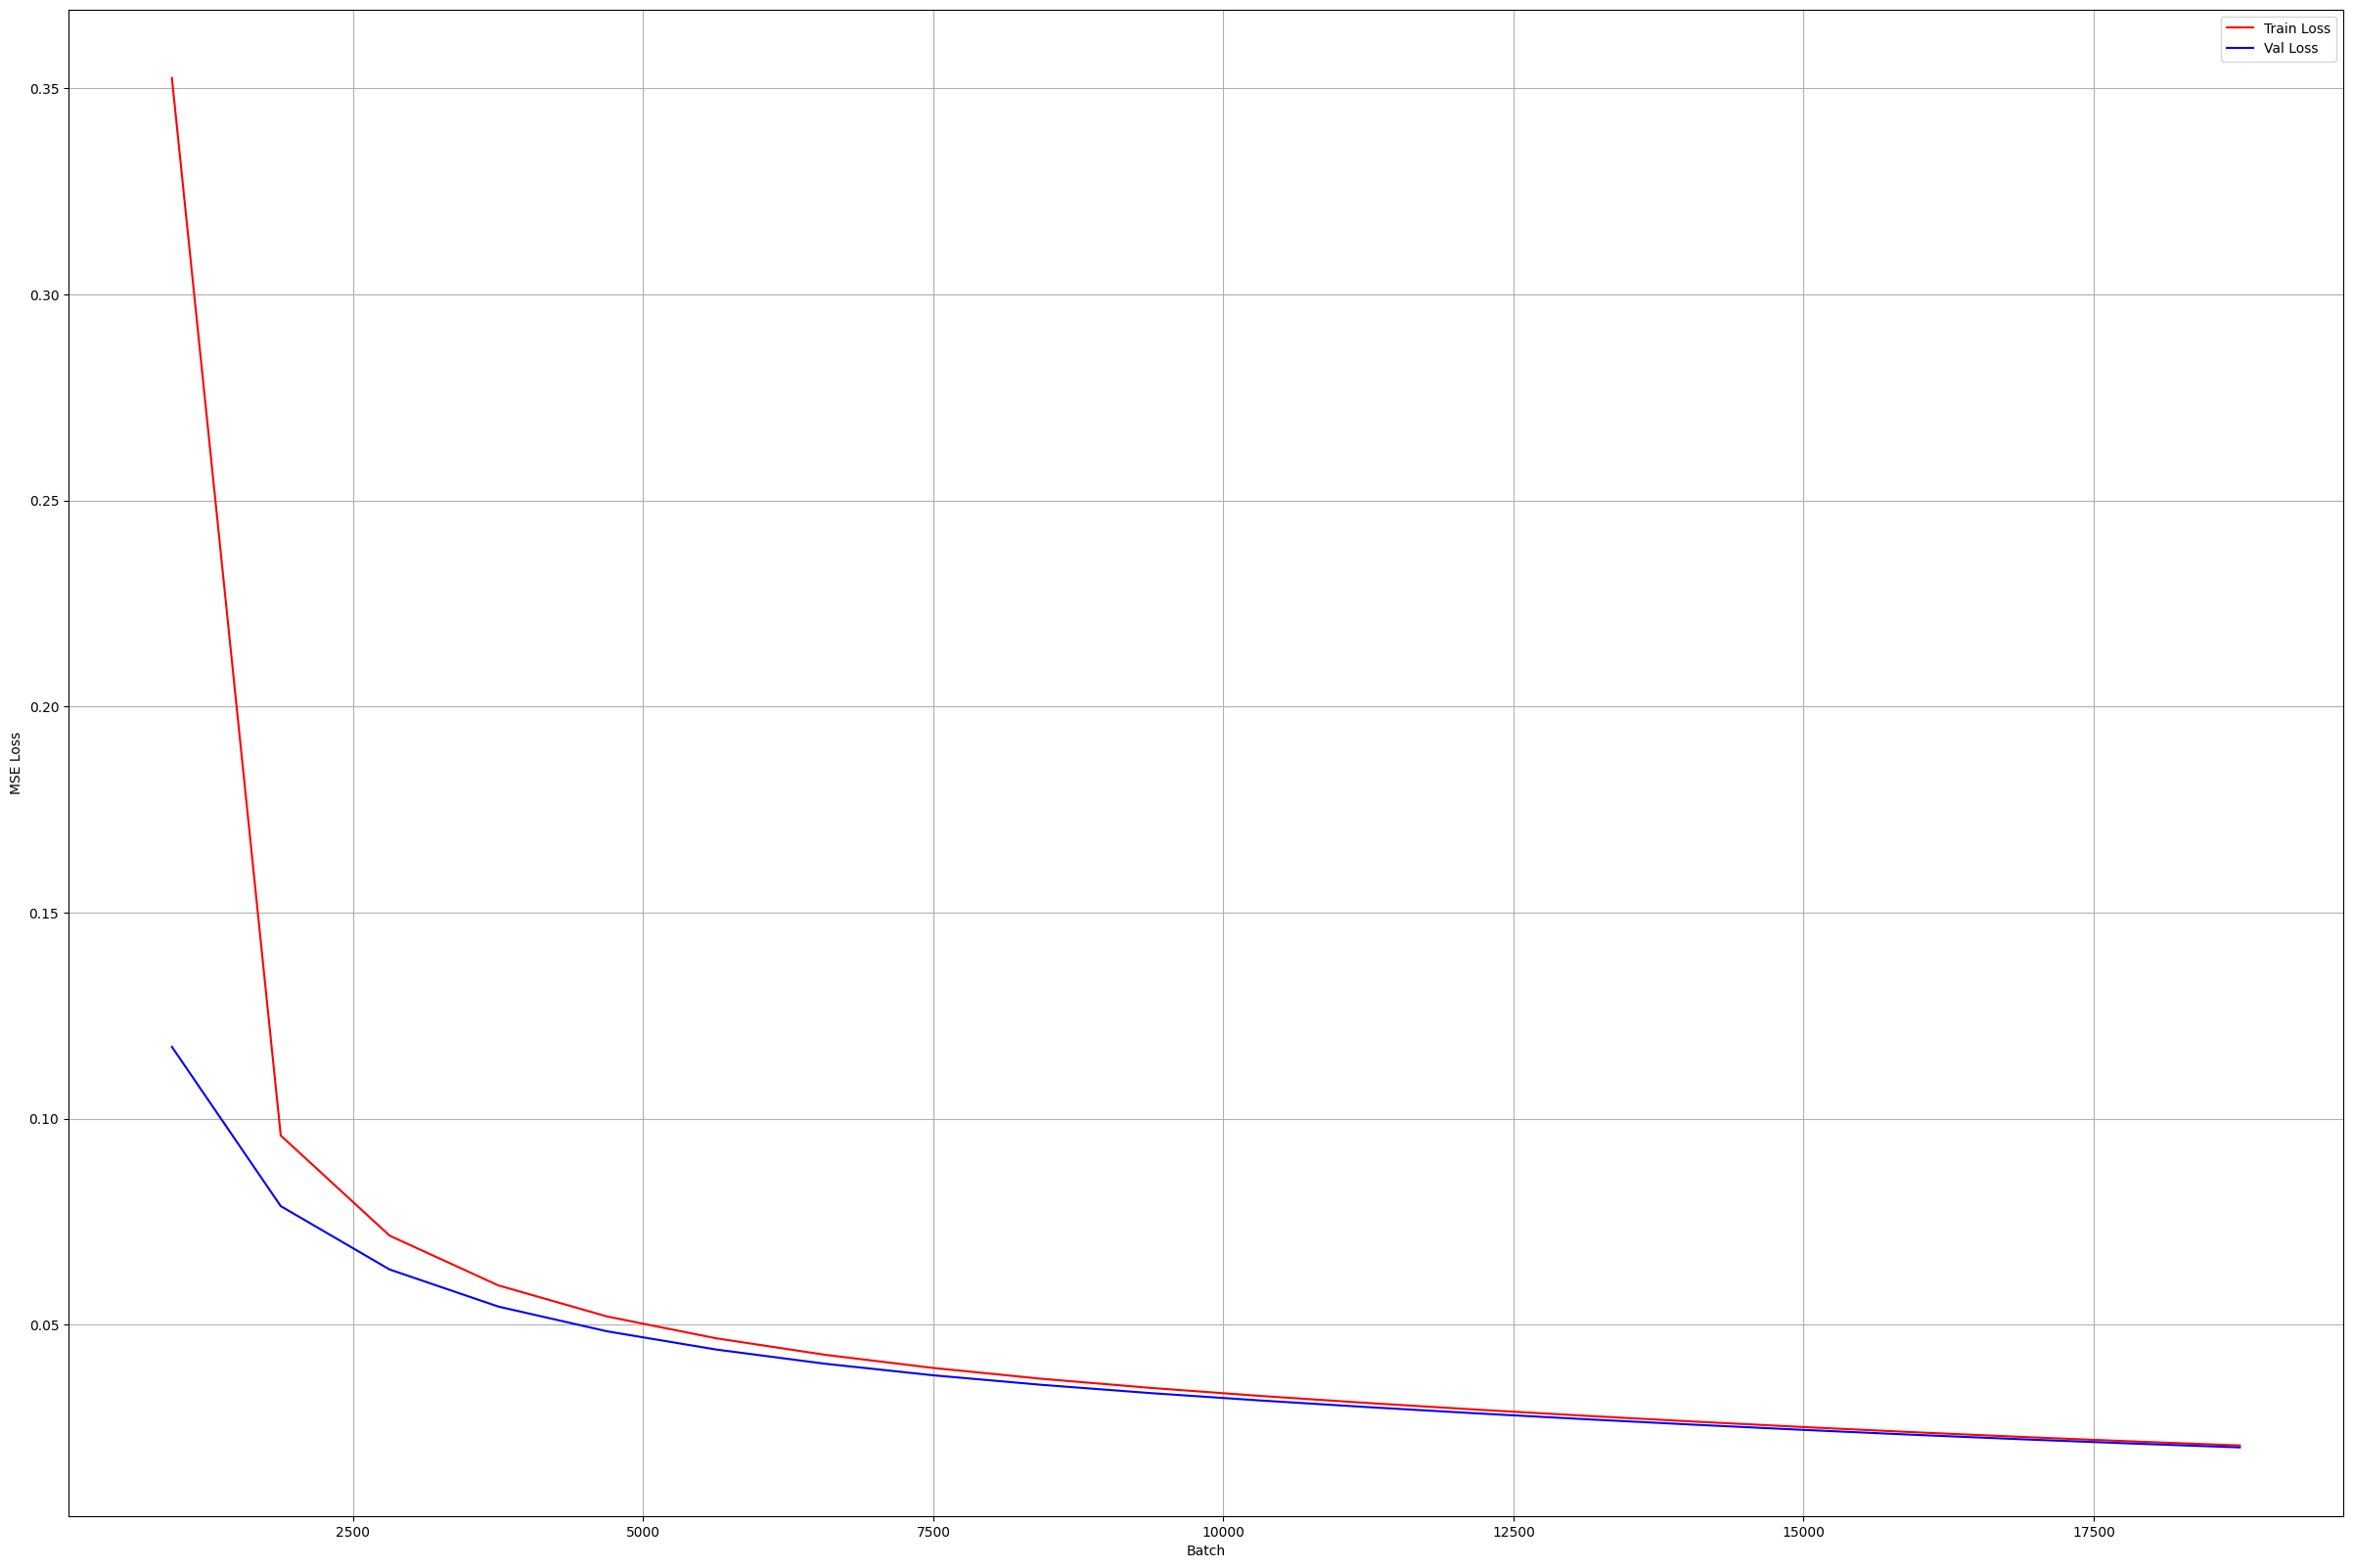

In [34]:
# Once the model roughly works I need to plot loss changes and determine over or under
# fitting
fig, ax = plt.subplots(figsize=[30, 20])
batch_counts = np.arange(train_batches, train_batches*n_epochs + 1, train_batches)
train = ax.plot(batch_counts, train_means.ravel(), color='red', label='Train Loss')
test = ax.plot(batch_counts, test_means.ravel(), color='blue', label='Val Loss')
ax.legend()
ax.set(xlabel='Batch', ylabel='MSE Loss')
ax.grid()
fig.savefig('channels_test_v2.png')